In [1]:
!pip install ultralytics -q

import torch
print(torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.5 MB/s eta 0:00:00
False


In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [1]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!ls

kaggle.json  sample_data


In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d pallav23/icg-spacenet-sandox-yolo

Dataset URL: https://www.kaggle.com/datasets/pallav23/icg-spacenet-sandox-yolo
License(s): CC-BY-SA-4.0
100% 950M/950M [00:12<00:00, 82.4MB/s]



In [7]:
!unzip -q icg-spacenet-sandox-yolo.zip -d /content/

In [8]:
!find /content -maxdepth 3 -type d | grep -iE 'image|label|train|val|test'

/content/spacenet_buildings_yolo/labels
/content/spacenet_buildings_yolo/images


In [9]:
import glob

print("Images:", len(glob.glob('/content/**/*.png', recursive=True)))
print("Labels:", len(glob.glob('/content/**/*.txt', recursive=True)))

Images: 1148
Labels: 1148


In [10]:
!find /content -maxdepth 3 -type d | grep -iE 'image|label|train|val|test'

/content/spacenet_buildings_yolo/labels
/content/spacenet_buildings_yolo/images


In [11]:
import glob

print(glob.glob('/content/**/*.png', recursive=True)[:5])

['/content/spacenet_buildings_yolo/images/AOI_3_Paris_img233.png', '/content/spacenet_buildings_yolo/images/AOI_3_Paris_img930.png', '/content/spacenet_buildings_yolo/images/AOI_3_Paris_img412.png', '/content/spacenet_buildings_yolo/images/AOI_3_Paris_img1487.png', '/content/spacenet_buildings_yolo/images/AOI_3_Paris_img491.png']


In [13]:
import os
import glob
import random
import shutil

SRC = "/content/spacenet_buildings_yolo"
BASE = "/content/dataset"

for split in ["train", "val", "test"]:
    os.makedirs(f"{BASE}/images/{split}", exist_ok=True)
    os.makedirs(f"{BASE}/labels/{split}", exist_ok=True)

imgs = glob.glob(f"{SRC}/images/*.png")

random.seed(42)
random.shuffle(imgs)

n = len(imgs)

train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_imgs = imgs[:train_end]
val_imgs = imgs[train_end:val_end]
test_imgs = imgs[val_end:]

splits = {
    "train": train_imgs,
    "val": val_imgs,
    "test": test_imgs
}

for split_name, image_list in splits.items():

    for img_path in image_list:

        img_name = os.path.basename(img_path)
        stem = os.path.splitext(img_name)[0]

        label_path = f"{SRC}/labels/{stem}.txt"

        shutil.copy(img_path,
                    f"{BASE}/images/{split_name}/{img_name}")

        if os.path.exists(label_path):
            shutil.copy(label_path,
                        f"{BASE}/labels/{split_name}/{stem}.txt")
        else:
            open(
                f"{BASE}/labels/{split_name}/{stem}.txt",
                "w"
            ).close()

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))

Train: 918
Val: 115
Test: 115


In [14]:
%%writefile /content/dataset.yaml

path: /content/dataset

train: images/train
val: images/val
test: images/test

nc: 1

names:
  - building

Writing /content/dataset.yaml


In [15]:
!cat /content/dataset.yaml


path: /content/dataset

train: images/train
val: images/val
test: images/test

nc: 1

names:
  - building


In [16]:
import glob

print("Train Images:", len(glob.glob("/content/dataset/images/train/*.png")))
print("Val Images:", len(glob.glob("/content/dataset/images/val/*.png")))
print("Test Images:", len(glob.glob("/content/dataset/images/test/*.png")))

Train Images: 918
Val Images: 115
Test Images: 115


In [2]:
import glob

print("PNG:", len(glob.glob("/content/dataset/images/train/*.png")))
print("JPG:", len(glob.glob("/content/dataset/images/train/*.jpg")))

PNG: 0
JPG: 0


In [3]:
!ls /content/dataset/images/train | head

ls: cannot access '/content/dataset/images/train': No such file or directory


In [4]:
!ls /content

sample_data


In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"saanviverma12","key":"3857208d73ca7430c1425f7051811cbf"}'}

In [6]:
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d pallav23/icg-spacenet-sandox-yolo

Dataset URL: https://www.kaggle.com/datasets/pallav23/icg-spacenet-sandox-yolo
License(s): CC-BY-SA-4.0
100% 950M/950M [00:08<00:00, 119MB/s]



In [8]:
!unzip -q icg-spacenet-sandox-yolo.zip -d /content/

In [9]:
!ls /content

icg-spacenet-sandox-yolo.zip  kaggle.json  sample_data	spacenet_buildings_yolo


In [10]:
import os
import glob
import random
import shutil

SRC = "/content/spacenet_buildings_yolo"
BASE = "/content/dataset"

for split in ["train", "val", "test"]:
    os.makedirs(f"{BASE}/images/{split}", exist_ok=True)
    os.makedirs(f"{BASE}/labels/{split}", exist_ok=True)

imgs = glob.glob(f"{SRC}/images/*")

random.seed(42)
random.shuffle(imgs)

n = len(imgs)

train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_imgs = imgs[:train_end]
val_imgs = imgs[train_end:val_end]
test_imgs = imgs[val_end:]

splits = {
    "train": train_imgs,
    "val": val_imgs,
    "test": test_imgs
}

for split_name, image_list in splits.items():

    for img_path in image_list:

        img_name = os.path.basename(img_path)
        stem = os.path.splitext(img_name)[0]

        label_path = f"{SRC}/labels/{stem}.txt"

        shutil.copy(
            img_path,
            f"{BASE}/images/{split_name}/{img_name}"
        )

        if os.path.exists(label_path):
            shutil.copy(
                label_path,
                f"{BASE}/labels/{split_name}/{stem}.txt"
            )
        else:
            open(
                f"{BASE}/labels/{split_name}/{stem}.txt",
                "w"
            ).close()

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))

Train: 918
Val: 115
Test: 115


In [11]:
%%writefile /content/dataset.yaml

path: /content/dataset

train: images/train
val: images/val
test: images/test

nc: 1

names:
  - building

Writing /content/dataset.yaml


In [12]:
!find /content/dataset -maxdepth 2 -type d

/content/dataset
/content/dataset/labels
/content/dataset/labels/test
/content/dataset/labels/train
/content/dataset/labels/val
/content/dataset/images
/content/dataset/images/test
/content/dataset/images/train
/content/dataset/images/val


In [13]:
import glob

print("Train Images:", len(glob.glob("/content/dataset/images/train/*")))
print("Val Images:", len(glob.glob("/content/dataset/images/val/*")))
print("Test Images:", len(glob.glob("/content/dataset/images/test/*")))

Train Images: 918
Val Images: 115
Test Images: 115


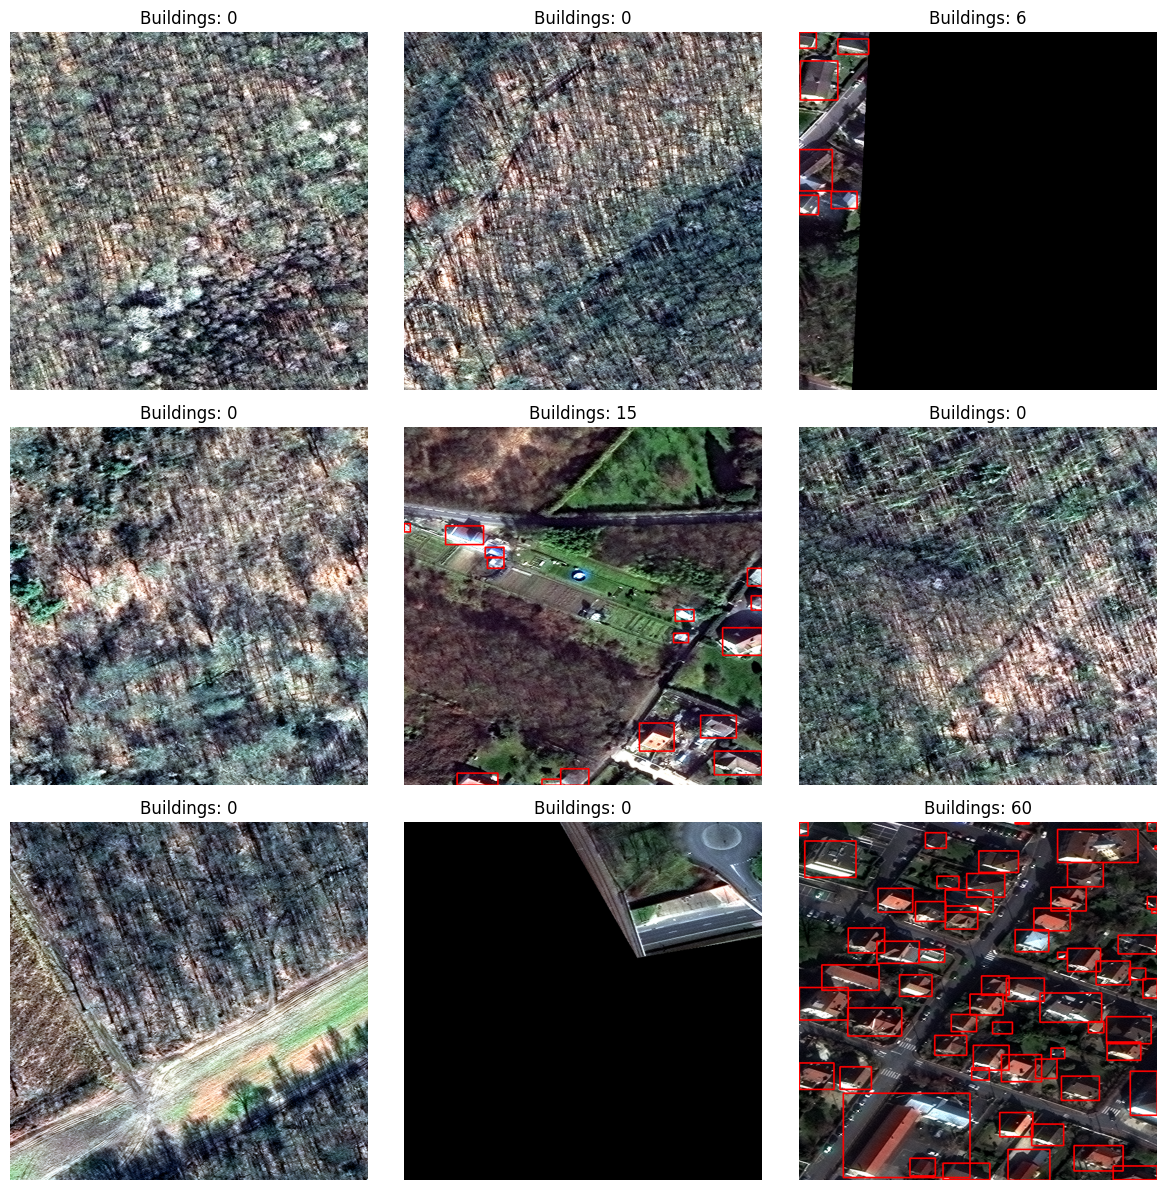

In [14]:
import cv2
import random
import matplotlib.pyplot as plt
import glob
import os

train_images = glob.glob("/content/dataset/images/train/*")

sample_images = random.sample(train_images, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img_path in zip(axes.flatten(), sample_images):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    label_path = img_path.replace("/images/", "/labels/")
    label_path = os.path.splitext(label_path)[0] + ".txt"

    building_count = 0

    if os.path.exists(label_path):

        with open(label_path, "r") as f:
            lines = f.readlines()

        building_count = len(lines)

        for line in lines:

            cls, cx, cy, bw, bh = map(float, line.strip().split())

            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    ax.imshow(img)
    ax.set_title(f"Buildings: {building_count}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
import glob

label_files = glob.glob("/content/dataset/labels/train/*.txt")

total_buildings = 0

for file in label_files:
    with open(file, "r") as f:
        total_buildings += len(f.readlines())

avg_buildings = total_buildings / len(label_files)

print("Average buildings per image:", round(avg_buildings, 2))

Average buildings per image: 14.77



Average buildings per image: 14.77

The satellite images appear consistent in size and quality.

Potential challenges:
• Small rooftops
• Dense building clusters
• Shadows
• Closely packed buildings
> Add blockquote



In [17]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.7 MB/s eta 0:00:00


In [18]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")
print("YOLO loaded successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO loaded successfully


In [19]:
model.train(
    data="/content/dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    name="building_detector"
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=building_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f07aa445640>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [21]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [22]:
!ls /content/runs/detect/building_detector

args.yaml			 results.csv	     val_batch0_labels.jpg
BoxF1_curve.png			 results.png	     val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg    val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg    val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg    val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch580.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch581.jpg  weights
labels.jpg			 train_batch582.jpg


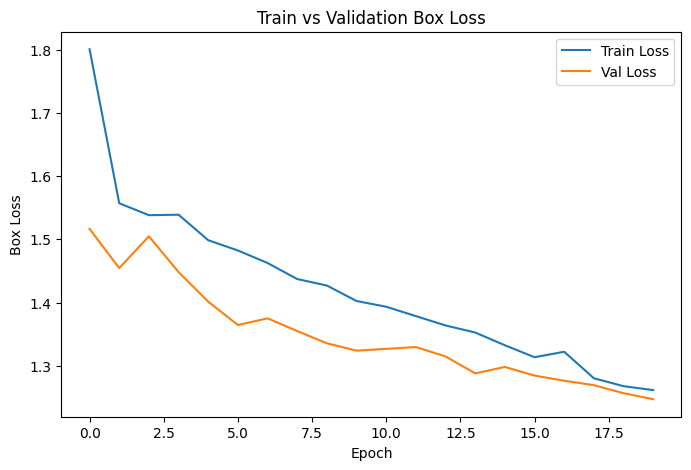

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/runs/detect/building_detector/results.csv')

plt.figure(figsize=(8,5))
plt.plot(df['train/box_loss'], label='Train Loss')
plt.plot(df['val/box_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Box Loss')
plt.title('Train vs Validation Box Loss')
plt.legend()
plt.show()

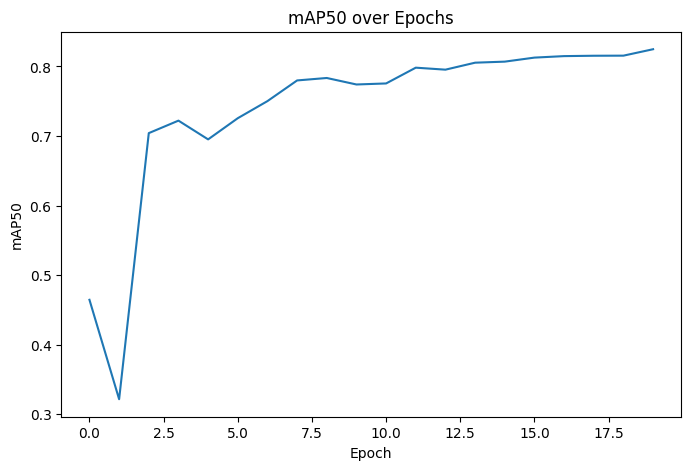

In [24]:
plt.figure(figsize=(8,5))
plt.plot(df['metrics/mAP50(B)'])
plt.xlabel('Epoch')
plt.ylabel('mAP50')
plt.title('mAP50 over Epochs')
plt.show()

The validation loss generally followed the training loss, indicating good learning behavior. The model continued improving throughout training and began to plateau near the final epochs.

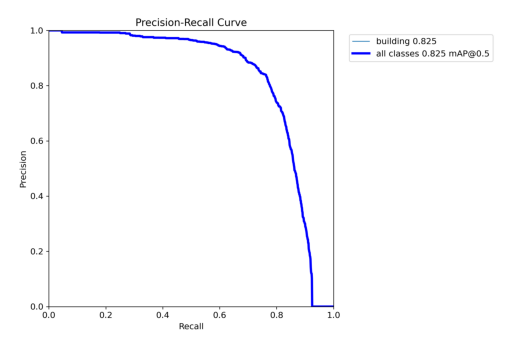

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/runs/detect/building_detector/BoxPR_curve.png')

plt.imshow(img)
plt.axis('off')
plt.show()

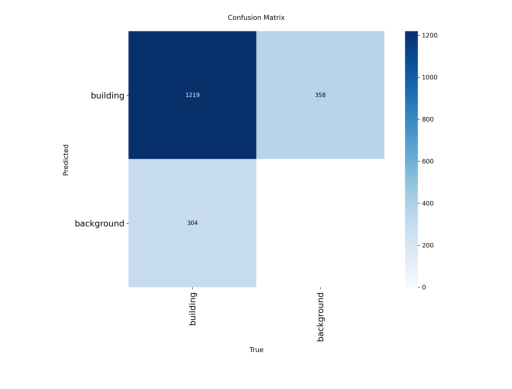

In [27]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/runs/detect/building_detector/confusion_matrix.png')

plt.imshow(img)
plt.axis('off')
plt.show()

In [29]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/building_detector/weights/best.pt')

def detect_buildings(image_path):

    results = model.predict(
        image_path,
        verbose=False
    )

    boxes = results[0].boxes

    count = len(boxes)

    if count > 0:
        avg_conf = float(boxes.conf.mean())
    else:
        avg_conf = 0

    return count, avg_conf, results

In [30]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

test_images = glob.glob('/content/dataset/images/test/*')[:10]

true_counts = []
pred_counts = []

for img_path in test_images:

    label_path = img_path.replace('/images/', '/labels/')
    label_path = os.path.splitext(label_path)[0] + '.txt'

    with open(label_path) as f:
        true_count = len(f.readlines())

    pred_count, _, _ = detect_buildings(img_path)

    true_counts.append(true_count)
    pred_counts.append(pred_count)

mae = np.mean(np.abs(
    np.array(true_counts) -
    np.array(pred_counts)
))

print("MAE =", round(mae, 2))

MAE = 2.4


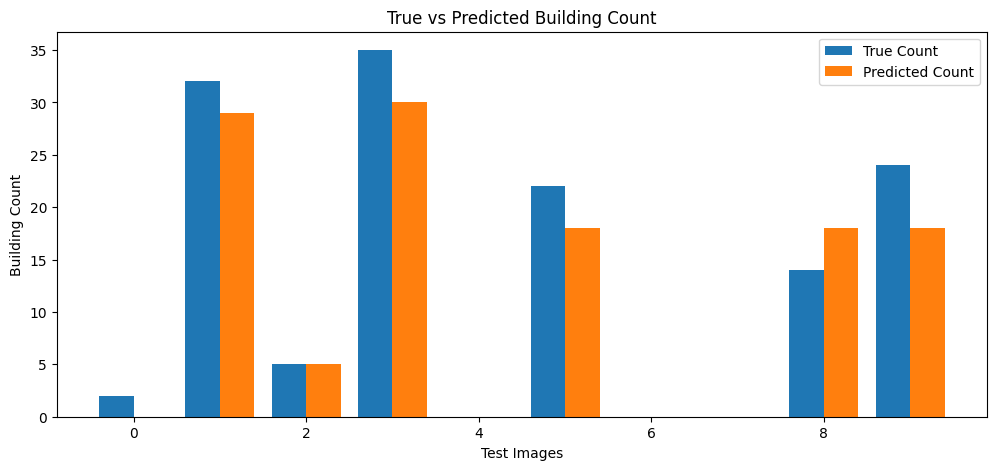

In [31]:
plt.figure(figsize=(12,5))

x = range(len(test_images))

plt.bar(
    [i-0.2 for i in x],
    true_counts,
    width=0.4,
    label='True Count'
)

plt.bar(
    [i+0.2 for i in x],
    pred_counts,
    width=0.4,
    label='Predicted Count'
)

plt.xlabel("Test Images")
plt.ylabel("Building Count")
plt.title("True vs Predicted Building Count")

plt.legend()

plt.show()

In [32]:
import cv2
import time
import matplotlib.pyplot as plt

def process_image(image_path):

    start = time.time()

    results = model.predict(
        image_path,
        verbose=False
    )

    elapsed = (
        time.time() - start
    ) * 1000

    count = len(results[0].boxes)

    if count > 0:
        avg_conf = float(
            results[0].boxes.conf.mean()
        )
    else:
        avg_conf = 0

    annotated = results[0].plot()

    original = cv2.imread(image_path)
    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    annotated = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(annotated)
    plt.title("Detected Buildings")
    plt.axis('off')

    plt.show()

    print(f"Image: {os.path.basename(image_path)}")
    print(f"Buildings detected: {count}")
    print(f"Avg confidence: {avg_conf:.2f}")
    print(f"Processing time: {elapsed:.1f} ms")

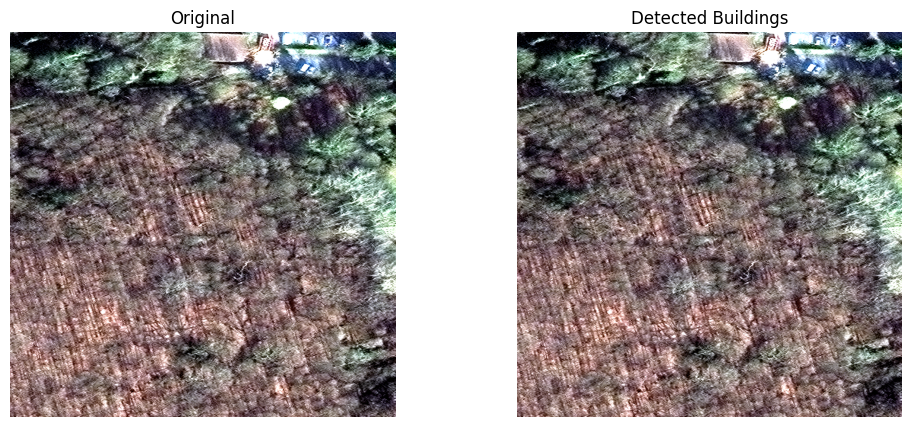

Image: AOI_3_Paris_img1889.png
Buildings detected: 0
Avg confidence: 0.00
Processing time: 44.5 ms


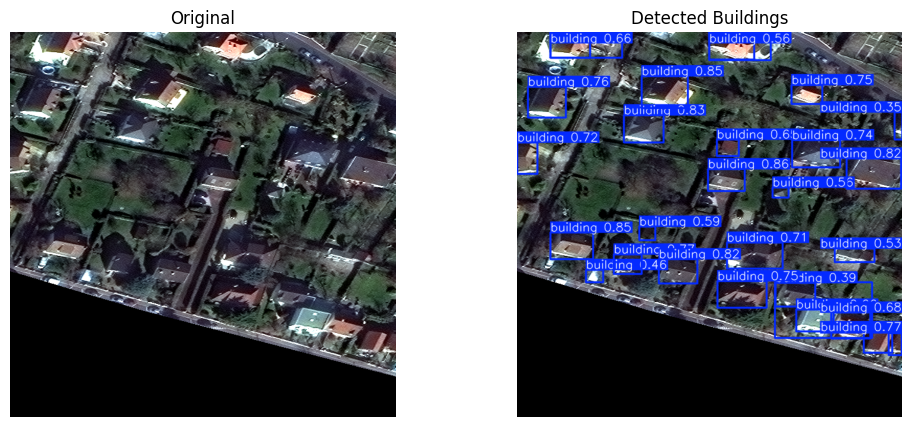

Image: AOI_3_Paris_img859.png
Buildings detected: 29
Avg confidence: 0.64
Processing time: 38.9 ms


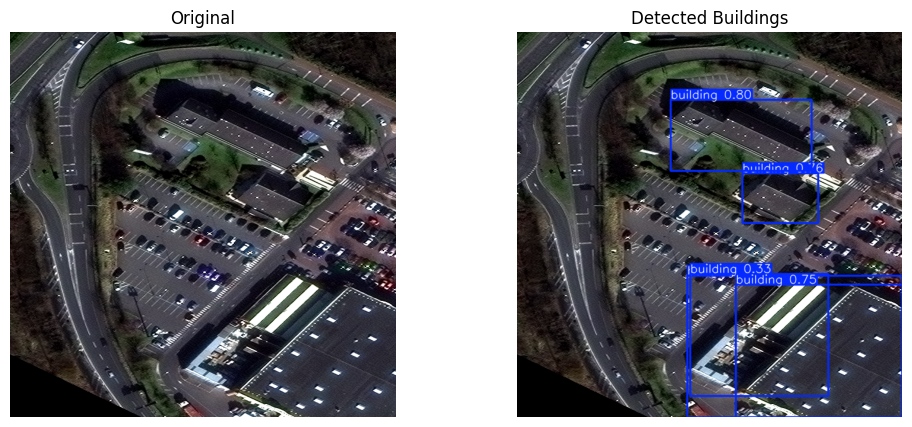

Image: AOI_3_Paris_img164.png
Buildings detected: 5
Avg confidence: 0.58
Processing time: 36.3 ms


In [33]:
for img in test_images[:3]:
    process_image(img)